# Build Dataset Funcionario V4 - Features para Dataset Maestro

Este notebook construye features agregadas de funcionarios para alimentar el dataset maestro.

El dataset de funcionario no será usado directamente para entrenar un modelo independiente. Su objetivo es generar variables agregadas a nivel de obra.

Salida principal:

data/processed/dataset_funcionario_v4_features_por_obra.parquet

Las columnas como DNI, nombres y documentos se utilizarán solo para trazabilidad o agregación, pero no como variables predictoras del modelo final.

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


BASE = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

DATA_EXT = BASE / "data" / "external" / "funcionario"
DATA_PROC = BASE / "data" / "processed"
REPORTS = BASE / "reports" / "figures"

DATA_PROC.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_EXT:", DATA_EXT)
print("DATA_PROC:", DATA_PROC)

BASE: C:\IA_Investigacion\Deteccion_Corrupcion
DATA_EXT: C:\IA_Investigacion\Deteccion_Corrupcion\data\external\funcionario
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed


In [3]:
def read_csv_robust(path: Path) -> pd.DataFrame:
    """
    Lee archivos CSV probando varias codificaciones.
    Esto evita errores por archivos que no están en UTF-8 puro.
    """
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    last_error = None

    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.attrs["encoding"] = enc
            return df
        except Exception as exc:
            last_error = exc

    raise last_error


def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normaliza nombres de columnas:
    - quita espacios
    - elimina BOM
    - reemplaza espacios por _
    - convierte a mayúsculas
    """
    out = df.copy()
    out.columns = (
        out.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.upper()
    )
    return out


def normalize_key(s: pd.Series) -> pd.Series:
    """
    Normaliza llaves como DNI, RUC o CODIGO_OBRA.
    """
    return (
        s.astype(str)
        .str.strip()
        .str.replace(".0", "", regex=False)
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )


FILES = {
    "m1a": "DS_DASH_Miembro_1A.csv",
    "m2a": "DS_DASH_Miembro_2A.csv",
    "m3a": "DS_DASH_Miembro_3A.csv",
    "m3b": "DS_DASH_Miembro_3B.csv",
}

tablas = {}

for key, fname in FILES.items():
    path = DATA_EXT / fname

    if not path.exists():
        alt = Path("/mnt/data") / fname
        path = alt if alt.exists() else path

    df = read_csv_robust(path)
    df = normalize_cols(df)

    tablas[key] = df

    print(f"{key}: {fname}")
    print("  Shape:", df.shape)
    print("  Encoding:", df.attrs.get("encoding"))
    print("  Columnas:", list(df.columns))
    print("-" * 100)

m1a: DS_DASH_Miembro_1A.csv
  Shape: (1613, 10)
  Encoding: latin1
  Columnas: ['CODIGO_OBRA', 'CODIGO_DNI', 'TIPO_DOCUMENTO', 'NOMBRE_COMPLETO', 'RESP_PENAL', 'RESP_ADMIN', 'RESP_CIVIL', 'SANCIONADA_SERVIR', 'SANCIONADA_RNP', 'INHABILITADOS_SERVIR']
----------------------------------------------------------------------------------------------------
m2a: DS_DASH_Miembro_2A.csv
  Shape: (739, 8)
  Encoding: latin1
  Columnas: ['CODIGO_DNI', 'TIPO_DOCUMENTO', 'NOMBRE_COMPLETO', 'RESP_PENAL', 'RESP_ADMIN', 'RESP_CIVIL', 'SANCIONADA_SERVIR', 'SANCIONADA_RNP']
----------------------------------------------------------------------------------------------------
m3a: DS_DASH_Miembro_3A.csv
  Shape: (2606, 4)
  Encoding: latin1
  Columnas: ['CODIGO_RUC', 'NOMBRE_EMPRESA', 'CODIGO_DNI', 'NOMBRE_MIEMBRO']
----------------------------------------------------------------------------------------------------
m3b: DS_DASH_Miembro_3B.csv
  Shape: (643, 4)
  Encoding: latin1
  Columnas: ['RUC_EMPRESA', 

In [4]:
# ===============================
# PASO 5: INVENTARIO EXACTO DE COLUMNAS
# ===============================

for key, df in tablas.items():
    print("\n" + "=" * 100)
    print(f"TABLA: {key}")
    print("=" * 100)
    print("Shape:", df.shape)
    print("\nColumnas exactas:")

    for i, col in enumerate(df.columns, start=1):
        print(f"{i:02d}. {col}")

    print("\nPrimeras 3 filas:")
    display(df.head(3))


TABLA: m1a
Shape: (1613, 10)

Columnas exactas:
01. CODIGO_OBRA
02. CODIGO_DNI
03. TIPO_DOCUMENTO
04. NOMBRE_COMPLETO
05. RESP_PENAL
06. RESP_ADMIN
07. RESP_CIVIL
08. SANCIONADA_SERVIR
09. SANCIONADA_RNP
10. INHABILITADOS_SERVIR

Primeras 3 filas:


,CODIGO_OBRA,CODIGO_DNI,TIPO_DOCUMENTO,NOMBRE_COMPLETO,RESP_PENAL,RESP_ADMIN,RESP_CIVIL,SANCIONADA_SERVIR,SANCIONADA_RNP,INHABILITADOS_SERVIR
0,19777,21461664,DNI,LUZ YOLANDA ESQUIVEL CERON,0,0,0,0,0,0
1,19777,32977736,DNI,Hugo Antonio Cotos Perez,0,4,4,0,0,0
2,19777,41798624,DNI,FREDDY MANCHA CASO,0,2,0,0,0,0



TABLA: m2a
Shape: (739, 8)

Columnas exactas:
01. CODIGO_DNI
02. TIPO_DOCUMENTO
03. NOMBRE_COMPLETO
04. RESP_PENAL
05. RESP_ADMIN
06. RESP_CIVIL
07. SANCIONADA_SERVIR
08. SANCIONADA_RNP

Primeras 3 filas:


,CODIGO_DNI,TIPO_DOCUMENTO,NOMBRE_COMPLETO,RESP_PENAL,RESP_ADMIN,RESP_CIVIL,SANCIONADA_SERVIR,SANCIONADA_RNP
0,10000679,DNI,GIANMARCO ANTONIO ANGULO CAIRO,0,0,0,0,0
1,10040819,DNI,RENE ALEJANDRO MONTALVO FLORES,0,0,0,0,0
2,10062144,DNI,LUZ ESMERALDA CORONEL CHAMORRO,0,0,0,0,0



TABLA: m3a
Shape: (2606, 4)

Columnas exactas:
01. CODIGO_RUC
02. NOMBRE_EMPRESA
03. CODIGO_DNI
04. NOMBRE_MIEMBRO

Primeras 3 filas:


,CODIGO_RUC,NOMBRE_EMPRESA,CODIGO_DNI,NOMBRE_MIEMBRO
0,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,40475086,ASENCION EZEQUIEL RIOS GALLARDO
1,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,44243793,MARIO ESLY WU VEGA
2,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,5339039,SEGUNDO GERMAN RIOS VASQUEZ



TABLA: m3b
Shape: (643, 4)

Columnas exactas:
01. RUC_EMPRESA
02. NOMBRE_EMPRESA
03. DNI_REPRESENTANTE
04. NOMBRE_REPRESENTANTE

Primeras 3 filas:


,RUC_EMPRESA,NOMBRE_EMPRESA,DNI_REPRESENTANTE,NOMBRE_REPRESENTANTE
0,10255871124,BENDAYAN MIGUEL JOSE LUIS(*),44272024,PADILLA PINCHI NATALY ROOS
1,20100153671,LAGESA INGENIEROS CONSULTORES S.A.,10223211,TONG CHANG DE MONTENEGRO ANGELA EUGENIA
2,20100153671,LAGESA INGENIEROS CONSULTORES S.A.,10491725,VILLANUEVA TARAZONA MARCO ERIC


In [5]:
# ===============================
# RESUMEN TABULAR DE COLUMNAS
# ===============================

rows = []

for key, df in tablas.items():
    for i, col in enumerate(df.columns, start=1):
        rows.append({
            "tabla": key,
            "orden": i,
            "columna": col,
            "dtype": str(df[col].dtype),
            "n_unicos": df[col].nunique(dropna=True),
            "n_nulos": df[col].isna().sum(),
            "pct_nulos": round(df[col].isna().mean() * 100, 2),
        })

cols_df = pd.DataFrame(rows)

display(cols_df)

,tabla,orden,columna,dtype,n_unicos,n_nulos,pct_nulos
0,m1a,1,CODIGO_OBRA,int64,178,0,0.0
1,m1a,2,CODIGO_DNI,int64,739,0,0.0
2,m1a,3,TIPO_DOCUMENTO,object,1,0,0.0
3,m1a,4,NOMBRE_COMPLETO,object,736,0,0.0
4,m1a,5,RESP_PENAL,int64,13,0,0.0
5,m1a,6,RESP_ADMIN,int64,16,0,0.0
6,m1a,7,RESP_CIVIL,int64,9,0,0.0
7,m1a,8,SANCIONADA_SERVIR,int64,2,0,0.0
8,m1a,9,SANCIONADA_RNP,int64,2,0,0.0
9,m1a,10,INHABILITADOS_SERVIR,int64,2,0,0.0


In [6]:
# ===============================
# PASO 6: NORMALIZACIÓN DE LLAVES
# ===============================

# Trabajaremos sobre copias
m1a = tablas["m1a"].copy()
m2a = tablas["m2a"].copy()
m3a = tablas["m3a"].copy()
m3b = tablas["m3b"].copy()


def normalize_key(s: pd.Series) -> pd.Series:
    """
    Normaliza IDs:
    - convierte a texto
    - elimina espacios
    - elimina '.0'
    """
    return (
        s.astype(str)
        .str.strip()
        .str.replace(".0", "", regex=False)
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan,
        })
    )


# ===============================
# NORMALIZAR M1A
# ===============================

m1a["CODIGO_OBRA"] = normalize_key(m1a["CODIGO_OBRA"])
m1a["CODIGO_DNI"] = normalize_key(m1a["CODIGO_DNI"])


# ===============================
# NORMALIZAR M2A
# ===============================

m2a["CODIGO_DNI"] = normalize_key(m2a["CODIGO_DNI"])


# ===============================
# NORMALIZAR M3A
# ===============================

m3a["CODIGO_RUC"] = normalize_key(m3a["CODIGO_RUC"])
m3a["CODIGO_DNI"] = normalize_key(m3a["CODIGO_DNI"])


# ===============================
# NORMALIZAR M3B
# ===============================

m3b["RUC_EMPRESA"] = normalize_key(m3b["RUC_EMPRESA"])
m3b["DNI_REPRESENTANTE"] = normalize_key(m3b["DNI_REPRESENTANTE"])


print("Normalización completada.")

Normalización completada.


In [7]:
# ===============================
# VALIDACIÓN POST NORMALIZACIÓN
# ===============================

print("=" * 100)
print("M1A")
print("=" * 100)

print("CODIGO_OBRA únicos:", m1a["CODIGO_OBRA"].nunique())
print("CODIGO_DNI únicos:", m1a["CODIGO_DNI"].nunique())

display(
    m1a[[
        "CODIGO_OBRA",
        "CODIGO_DNI",
        "NOMBRE_COMPLETO"
    ]].head()
)

print("\n" + "=" * 100)
print("M2A")
print("=" * 100)

print("CODIGO_DNI únicos:", m2a["CODIGO_DNI"].nunique())

display(
    m2a[[
        "CODIGO_DNI",
        "NOMBRE_COMPLETO"
    ]].head()
)

print("\n" + "=" * 100)
print("M3A")
print("=" * 100)

print("CODIGO_RUC únicos:", m3a["CODIGO_RUC"].nunique())
print("CODIGO_DNI únicos:", m3a["CODIGO_DNI"].nunique())

display(
    m3a[[
        "CODIGO_RUC",
        "CODIGO_DNI",
        "NOMBRE_MIEMBRO"
    ]].head()
)

print("\n" + "=" * 100)
print("M3B")
print("=" * 100)

print("RUC_EMPRESA únicos:", m3b["RUC_EMPRESA"].nunique())
print("DNI_REPRESENTANTE únicos:", m3b["DNI_REPRESENTANTE"].nunique())

display(
    m3b[[
        "RUC_EMPRESA",
        "DNI_REPRESENTANTE",
        "NOMBRE_REPRESENTANTE"
    ]].head()
)

M1A
CODIGO_OBRA únicos: 178
CODIGO_DNI únicos: 739


,CODIGO_OBRA,CODIGO_DNI,NOMBRE_COMPLETO
0,19777,21461664,LUZ YOLANDA ESQUIVEL CERON
1,19777,32977736,Hugo Antonio Cotos Perez
2,19777,41798624,FREDDY MANCHA CASO
3,19777,43584310,MARIA CECILIA PIÑAN INDACOCHEA
4,19777,9382177,ELKA CAROLINA ROSALES LAURENTE



M2A
CODIGO_DNI únicos: 739


,CODIGO_DNI,NOMBRE_COMPLETO
0,10000679,GIANMARCO ANTONIO ANGULO CAIRO
1,10040819,RENE ALEJANDRO MONTALVO FLORES
2,10062144,LUZ ESMERALDA CORONEL CHAMORRO
3,10066521,ALFREDO ADALBERTO MORENO PISCONTE
4,10110638,RAUL SEVERINO CANCHO



M3A
CODIGO_RUC únicos: 313
CODIGO_DNI únicos: 737


,CODIGO_RUC,CODIGO_DNI,NOMBRE_MIEMBRO
0,10001046191,40475086,ASENCION EZEQUIEL RIOS GALLARDO
1,10001046191,44243793,MARIO ESLY WU VEGA
2,10001046191,5339039,SEGUNDO GERMAN RIOS VASQUEZ
3,10001046191,5402152,ABDY RODRIGUEZ MONTALVAN
4,10001046191,5403466,MARIO RENE GONZALES MOREY



M3B
RUC_EMPRESA únicos: 240
DNI_REPRESENTANTE únicos: 629


,RUC_EMPRESA,DNI_REPRESENTANTE,NOMBRE_REPRESENTANTE
0,10255871124,44272024,PADILLA PINCHI NATALY ROOS
1,20100153671,10223211,TONG CHANG DE MONTENEGRO ANGELA EUGENIA
2,20100153671,10491725,VILLANUEVA TARAZONA MARCO ERIC
3,20100153671,15590169,MORALES GONZALES PEDRO ELMER
4,20100153671,15605774,HIJAR DIAZ MARTHA MATILDE


### Paso 7: construcción del funcionario base y señales de riesgo

#### CONSOLIDAR FUNCIONARIOS

In [8]:
# ===============================
# PASO 7.1: FUNCIONARIO BASE
# ===============================

# Base principal: funcionarios únicos
func_base = m2a.copy()

print("func_base inicial:", func_base.shape)

# ===============================
# AGREGAR CANTIDAD DE OBRAS
# ===============================

obras_por_func = (
    m1a.groupby("CODIGO_DNI")
    .agg(
        func_n_obras=("CODIGO_OBRA", "nunique"),
        func_n_registros_obra=("CODIGO_OBRA", "size"),
    )
    .reset_index()
)

func_base = func_base.merge(
    obras_por_func,
    on="CODIGO_DNI",
    how="left"
)

# ===============================
# AGREGAR CANTIDAD DE EMPRESAS
# ===============================

empresas_por_func = (
    m3a.groupby("CODIGO_DNI")
    .agg(
        func_n_empresas=("CODIGO_RUC", "nunique"),
        func_n_vinculos_empresa=("CODIGO_RUC", "size"),
    )
    .reset_index()
)

func_base = func_base.merge(
    empresas_por_func,
    on="CODIGO_DNI",
    how="left"
)

# ===============================
# AGREGAR REPRESENTACIONES
# ===============================

representaciones = (
    m3b.groupby("DNI_REPRESENTANTE")
    .agg(
        func_n_empresas_representadas=("RUC_EMPRESA", "nunique"),
        func_n_representaciones=("RUC_EMPRESA", "size"),
    )
    .reset_index()
    .rename(columns={
        "DNI_REPRESENTANTE": "CODIGO_DNI"
    })
)

func_base = func_base.merge(
    representaciones,
    on="CODIGO_DNI",
    how="left"
)

# ===============================
# COMPLETAR NULOS
# ===============================

num_cols = [
    "func_n_obras",
    "func_n_registros_obra",
    "func_n_empresas",
    "func_n_vinculos_empresa",
    "func_n_empresas_representadas",
    "func_n_representaciones",
]

for col in num_cols:
    if col in func_base.columns:
        func_base[col] = func_base[col].fillna(0)

print("func_base final:", func_base.shape)

display(func_base.head())

func_base inicial: (739, 8)
func_base final: (739, 14)


,CODIGO_DNI,TIPO_DOCUMENTO,NOMBRE_COMPLETO,RESP_PENAL,RESP_ADMIN,RESP_CIVIL,SANCIONADA_SERVIR,SANCIONADA_RNP,func_n_obras,func_n_registros_obra,func_n_empresas,func_n_vinculos_empresa,func_n_empresas_representadas,func_n_representaciones
0,10000679,DNI,GIANMARCO ANTONIO ANGULO CAIRO,0,0,0,0,0,4,10,17.0,17.0,0.0,0.0
1,10040819,DNI,RENE ALEJANDRO MONTALVO FLORES,0,0,0,0,0,1,1,2.0,2.0,0.0,0.0
2,10062144,DNI,LUZ ESMERALDA CORONEL CHAMORRO,0,0,0,0,0,1,2,4.0,4.0,0.0,0.0
3,10066521,DNI,ALFREDO ADALBERTO MORENO PISCONTE,0,0,0,0,0,1,1,3.0,3.0,0.0,0.0
4,10110638,DNI,RAUL SEVERINO CANCHO,0,0,0,0,0,1,2,3.0,3.0,0.0,0.0


#### SCORE DE RIESGO

In [9]:
# ===============================
# PASO 7.2: SCORE DE RIESGO
# ===============================

risk_cols = [
    "RESP_PENAL",
    "RESP_ADMIN",
    "RESP_CIVIL",
    "SANCIONADA_SERVIR",
    "SANCIONADA_RNP",
]

for col in risk_cols:
    if col in func_base.columns:
        func_base[col] = pd.to_numeric(
            func_base[col],
            errors="coerce"
        ).fillna(0)

# ===============================
# SCORE RESPONSABILIDADES
# ===============================

func_base["score_responsabilidad"] = (
    func_base["RESP_PENAL"] * 3 +
    func_base["RESP_ADMIN"] * 2 +
    func_base["RESP_CIVIL"] * 1
)

# ===============================
# SCORE SANCIONES
# ===============================

func_base["score_sancion"] = (
    func_base["SANCIONADA_SERVIR"] * 2 +
    func_base["SANCIONADA_RNP"] * 2
)

# ===============================
# SCORE TOTAL
# ===============================

func_base["score_riesgo_funcionario"] = (
    func_base["score_responsabilidad"] +
    func_base["score_sancion"]
)

print("Score generado.")

display(
    func_base[[
        "CODIGO_DNI",
        "score_responsabilidad",
        "score_sancion",
        "score_riesgo_funcionario"
    ]].head()
)

Score generado.


,CODIGO_DNI,score_responsabilidad,score_sancion,score_riesgo_funcionario
0,10000679,0,0,0
1,10040819,0,0,0
2,10062144,0,0,0
3,10066521,0,0,0
4,10110638,0,0,0


#### NIVELES DE RIESGO ( 4 )

In [10]:
# ===============================
# PASO 7.3: 4 NIVELES DE RIESGO
# ===============================

def score_to_4niveles(score):

    if score <= 0:
        return 0

    elif score <= 5:
        return 1

    elif score <= 15:
        return 2

    else:
        return 3


func_base["y_riesgo_funcionario_4niveles"] = (
    func_base["score_riesgo_funcionario"]
    .apply(score_to_4niveles)
    .astype(int)
)

print("Distribución de riesgo:")

display(
    func_base["y_riesgo_funcionario_4niveles"]
    .value_counts()
    .sort_index()
    .to_frame("cantidad")
)

Distribución de riesgo:


,cantidad
y_riesgo_funcionario_4niveles,
0,592
1,36
2,58
3,53


### Paso 8: construir features de funcionario por obra

##### 8.1: unir vínculo obra-funcionario con perfil del funcionario

In [11]:
# ===============================
# PASO 8.1: VÍNCULO OBRA-FUNCIONARIO ENRIQUECIDO
# ===============================

# Base de vínculo obra-funcionario
func_obra = m1a.copy()

# Nos quedamos con las columnas de vínculo y trazabilidad
cols_func_obra = [
    "CODIGO_OBRA",
    "CODIGO_DNI",
    "NOMBRE_COMPLETO",
]

# Agregamos solo columnas que existan
cols_func_obra = [c for c in cols_func_obra if c in func_obra.columns]

func_obra = func_obra[cols_func_obra].drop_duplicates()

# Perfil de funcionario que se integrará al vínculo
cols_func_profile = [
    "CODIGO_DNI",
    "func_n_obras",
    "func_n_registros_obra",
    "func_n_empresas",
    "func_n_vinculos_empresa",
    "func_n_empresas_representadas",
    "func_n_representaciones",
    "score_responsabilidad",
    "score_sancion",
    "score_riesgo_funcionario",
    "y_riesgo_funcionario_4niveles",
]

cols_func_profile = [c for c in cols_func_profile if c in func_base.columns]

func_obra_enriched = func_obra.merge(
    func_base[cols_func_profile],
    on="CODIGO_DNI",
    how="left"
)

print("func_obra_enriched:", func_obra_enriched.shape)
print("Obras únicas:", func_obra_enriched["CODIGO_OBRA"].nunique())
print("Funcionarios únicos:", func_obra_enriched["CODIGO_DNI"].nunique())

display(func_obra_enriched.head())

func_obra_enriched: (1329, 13)
Obras únicas: 178
Funcionarios únicos: 739


,CODIGO_OBRA,CODIGO_DNI,NOMBRE_COMPLETO,func_n_obras,func_n_registros_obra,func_n_empresas,func_n_vinculos_empresa,func_n_empresas_representadas,func_n_representaciones,score_responsabilidad,score_sancion,score_riesgo_funcionario,y_riesgo_funcionario_4niveles
0,19777,21461664,LUZ YOLANDA ESQUIVEL CERON,2,2,2.0,2.0,0.0,0.0,0,0,0,0
1,19777,32977736,Hugo Antonio Cotos Perez,2,2,2.0,2.0,0.0,0.0,12,0,12,2
2,19777,41798624,FREDDY MANCHA CASO,2,2,2.0,2.0,0.0,0.0,4,0,4,1
3,19777,43584310,MARIA CECILIA PIÑAN INDACOCHEA,6,6,11.0,11.0,0.0,0.0,0,0,0,0
4,19777,9382177,ELKA CAROLINA ROSALES LAURENTE,3,3,2.0,2.0,0.0,0.0,4,0,4,1


##### 8.2: validar que no se perdió información

In [12]:
# ===============================
# PASO 8.2: VALIDACIÓN DEL MERGE
# ===============================

print("Filas vínculo original:", len(func_obra))
print("Filas vínculo enriquecido:", len(func_obra_enriched))

missing_profile = func_obra_enriched["y_riesgo_funcionario_4niveles"].isna().sum()

print("Funcionarios sin perfil de riesgo:", missing_profile)

if missing_profile > 0:
    print("ADVERTENCIA: existen funcionarios vinculados a obra sin perfil en func_base.")
    display(
        func_obra_enriched[
            func_obra_enriched["y_riesgo_funcionario_4niveles"].isna()
        ].head()
    )

Filas vínculo original: 1329
Filas vínculo enriquecido: 1329
Funcionarios sin perfil de riesgo: 0


##### 8.3: crear features agregadas por obra

In [13]:
# ===============================
# PASO 8.3: FEATURES POR OBRA
# ===============================

# Asegurar numéricos
numeric_cols = [
    "func_n_obras",
    "func_n_registros_obra",
    "func_n_empresas",
    "func_n_vinculos_empresa",
    "func_n_empresas_representadas",
    "func_n_representaciones",
    "score_responsabilidad",
    "score_sancion",
    "score_riesgo_funcionario",
    "y_riesgo_funcionario_4niveles",
]

for col in numeric_cols:
    if col in func_obra_enriched.columns:
        func_obra_enriched[col] = pd.to_numeric(
            func_obra_enriched[col],
            errors="coerce"
        )

funcionario_por_obra = (
    func_obra_enriched
    .groupby("CODIGO_OBRA")
    .agg(
        func_n_funcionarios=("CODIGO_DNI", "nunique"),
        func_n_registros=("CODIGO_DNI", "size"),

        func_riesgo_max=("y_riesgo_funcionario_4niveles", "max"),
        func_riesgo_mean=("y_riesgo_funcionario_4niveles", "mean"),
        func_riesgo_std=("y_riesgo_funcionario_4niveles", "std"),

        func_score_max=("score_riesgo_funcionario", "max"),
        func_score_mean=("score_riesgo_funcionario", "mean"),
        func_score_std=("score_riesgo_funcionario", "std"),

        func_score_responsabilidad_mean=("score_responsabilidad", "mean"),
        func_score_sancion_mean=("score_sancion", "mean"),

        func_pct_alto_riesgo=(
            "y_riesgo_funcionario_4niveles",
            lambda s: (s >= 3).mean()
        ),
        func_pct_medio_o_alto=(
            "y_riesgo_funcionario_4niveles",
            lambda s: (s >= 2).mean()
        ),

        func_n_obras_mean=("func_n_obras", "mean"),
        func_n_obras_max=("func_n_obras", "max"),

        func_n_empresas_mean=("func_n_empresas", "mean"),
        func_n_empresas_max=("func_n_empresas", "max"),

        func_n_representaciones_mean=("func_n_representaciones", "mean"),
        func_n_representaciones_max=("func_n_representaciones", "max"),

        func_n_empresas_representadas_mean=(
            "func_n_empresas_representadas",
            "mean"
        ),
        func_n_empresas_representadas_max=(
            "func_n_empresas_representadas",
            "max"
        ),
    )
    .reset_index()
)

# Reemplazar std nulos por 0 cuando solo hay un funcionario
std_cols = [c for c in funcionario_por_obra.columns if c.endswith("_std")]
for col in std_cols:
    funcionario_por_obra[col] = funcionario_por_obra[col].fillna(0)

print("funcionario_por_obra:", funcionario_por_obra.shape)
display(funcionario_por_obra.head())

funcionario_por_obra: (178, 21)


,CODIGO_OBRA,func_n_funcionarios,func_n_registros,func_riesgo_max,func_riesgo_mean,func_riesgo_std,func_score_max,func_score_mean,func_score_std,func_score_responsabilidad_mean,...,func_pct_alto_riesgo,func_pct_medio_o_alto,func_n_obras_mean,func_n_obras_max,func_n_empresas_mean,func_n_empresas_max,func_n_representaciones_mean,func_n_representaciones_max,func_n_empresas_representadas_mean,func_n_empresas_representadas_max
0,102021,6,6,2,0.500000,0.836660,10,1.833333,4.020779,0.166667,...,0.000000,0.166667,3.166667,5,5.500000,8.0,0.0,0.0,0.0,0.0
1,102022,7,7,3,0.571429,1.133893,54,8.428571,20.181321,7.857143,...,0.142857,0.142857,2.714286,5,3.714286,8.0,0.0,0.0,0.0,0.0
2,102591,6,6,2,0.666667,1.032796,10,3.000000,4.690416,3.000000,...,0.000000,0.333333,4.000000,8,8.000000,13.0,0.0,0.0,0.0,0.0
3,105653,8,8,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.375000,9,11.625000,29.0,0.0,0.0,0.0,0.0
4,106748,8,8,3,0.375000,1.060660,24,3.000000,8.485281,3.000000,...,0.125000,0.125000,4.625000,11,6.375000,17.0,0.0,0.0,0.0,0.0


##### 8.4: validación de columnas prohibidas

In [14]:
# ===============================
# PASO 8.4: VALIDACIÓN DE SEGURIDAD
# ===============================

forbidden_terms = [
    "DNI",
    "NOMBRE",
    "APELLIDO",
    "DOCUMENTO",
    "RUC",
    "REPRESENTANTE",
    "MIEMBRO",
]

bad_cols = []

for col in funcionario_por_obra.columns:
    col_upper = col.upper()

    # CODIGO_OBRA se permite solo como llave temporal de integración
    if col == "CODIGO_OBRA":
        continue

    if any(term in col_upper for term in forbidden_terms):
        bad_cols.append(col)

print("Columnas sospechosas:", bad_cols)

if bad_cols:
    raise ValueError(
        f"funcionario_por_obra contiene columnas no permitidas: {bad_cols}"
    )

print("Validación OK: features por obra sin DNI, nombres ni identificadores personales.")

Columnas sospechosas: []
Validación OK: features por obra sin DNI, nombres ni identificadores personales.


### Paso 9: EDA mínimo y guardado del dataset funcionario

##### 9.1 — EDA BÁSICO

In [15]:
# ===============================
# PASO 9.1: EDA BÁSICO
# ===============================

print("=" * 100)
print("DATASET FUNCIONARIO POR OBRA")
print("=" * 100)

print("Shape:", funcionario_por_obra.shape)

print("\nColumnas:")
for c in funcionario_por_obra.columns:
    print("-", c)

print("\nTipos:")
display(
    funcionario_por_obra.dtypes.to_frame("dtype")
)

print("\nDescribe:")
display(
    funcionario_por_obra.describe().T
)

print("\nNulos:")
display(
    funcionario_por_obra.isna()
    .mean()
    .mul(100)
    .round(2)
    .to_frame("% nulos")
    .sort_values("% nulos", ascending=False)
)

DATASET FUNCIONARIO POR OBRA
Shape: (178, 21)

Columnas:
- CODIGO_OBRA
- func_n_funcionarios
- func_n_registros
- func_riesgo_max
- func_riesgo_mean
- func_riesgo_std
- func_score_max
- func_score_mean
- func_score_std
- func_score_responsabilidad_mean
- func_score_sancion_mean
- func_pct_alto_riesgo
- func_pct_medio_o_alto
- func_n_obras_mean
- func_n_obras_max
- func_n_empresas_mean
- func_n_empresas_max
- func_n_representaciones_mean
- func_n_representaciones_max
- func_n_empresas_representadas_mean
- func_n_empresas_representadas_max

Tipos:


,dtype
CODIGO_OBRA,object
func_n_funcionarios,int64
func_n_registros,int64
func_riesgo_max,int64
func_riesgo_mean,float64
func_riesgo_std,float64
func_score_max,int64
func_score_mean,float64
func_score_std,float64
func_score_responsabilidad_mean,float64



Describe:


,count,mean,std,min,25%,50%,75%,max
func_n_funcionarios,178.0,7.466292,2.566954,3.0,6.000000,6.000000,9.000000,18.000000
func_n_registros,178.0,7.466292,2.566954,3.0,6.000000,6.000000,9.000000,18.000000
func_riesgo_max,178.0,1.494382,1.298618,0.0,0.000000,2.000000,3.000000,3.000000
func_riesgo_mean,178.0,0.412410,0.469468,0.0,0.000000,0.333333,0.666667,2.166667
func_riesgo_std,178.0,0.634799,0.566033,0.0,0.000000,0.816497,1.080123,1.732051
func_score_max,178.0,13.983146,19.189650,0.0,0.000000,8.000000,19.500000,121.000000
func_score_mean,178.0,3.188169,4.928593,0.0,0.000000,1.825758,3.500000,31.833333
func_score_std,178.0,5.376138,7.325825,0.0,0.000000,3.932768,6.711274,49.398043
func_score_responsabilidad_mean,178.0,2.817204,4.552273,0.0,0.000000,1.333333,3.333333,29.833333
func_score_sancion_mean,178.0,0.370964,1.310146,0.0,0.000000,0.000000,0.000000,11.666667



Nulos:


,% nulos
CODIGO_OBRA,0.0
func_n_funcionarios,0.0
func_n_registros,0.0
func_riesgo_max,0.0
func_riesgo_mean,0.0
func_riesgo_std,0.0
func_score_max,0.0
func_score_mean,0.0
func_score_std,0.0
func_score_responsabilidad_mean,0.0


##### 9.2 — DISTRIBUCIONES PRINCIPALES

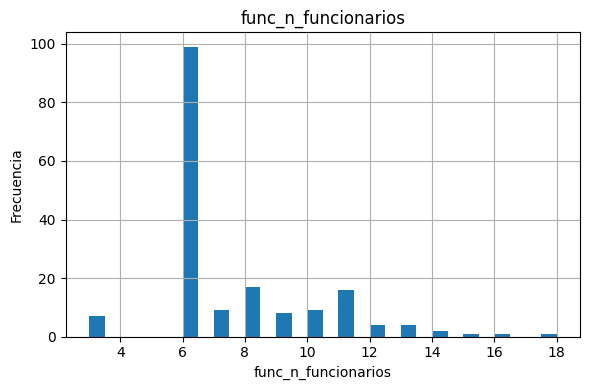

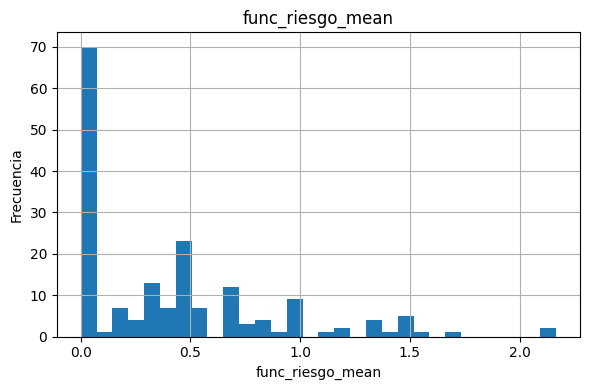

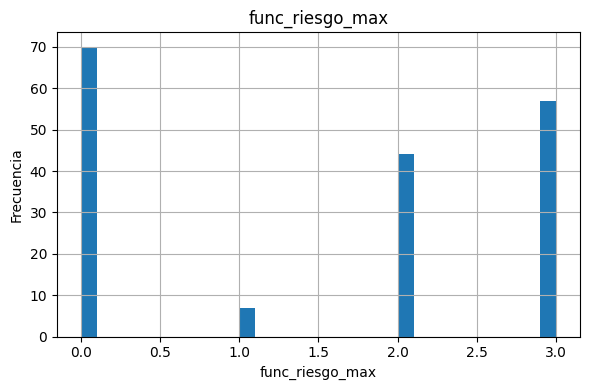

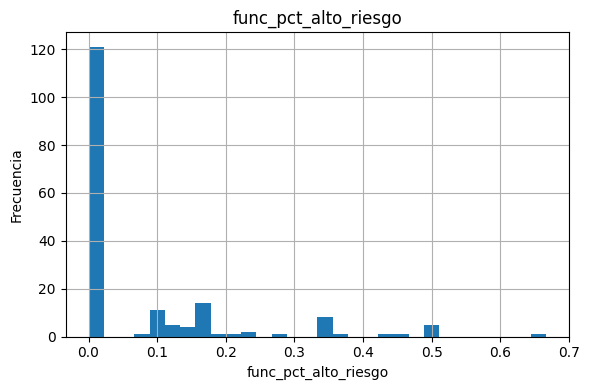

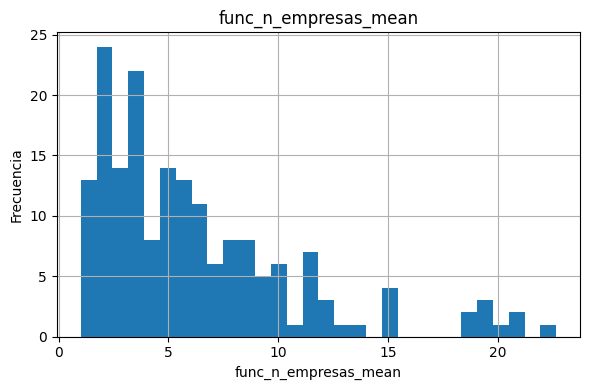

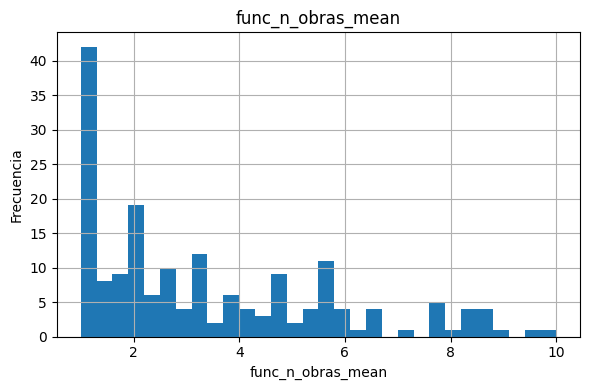

In [16]:
# ===============================
# PASO 9.2: DISTRIBUCIONES
# ===============================

if plt is not None:

    plot_cols = [
        "func_n_funcionarios",
        "func_riesgo_mean",
        "func_riesgo_max",
        "func_pct_alto_riesgo",
        "func_n_empresas_mean",
        "func_n_obras_mean",
    ]

    for col in plot_cols:

        if col not in funcionario_por_obra.columns:
            continue

        plt.figure(figsize=(6,4))

        funcionario_por_obra[col].hist(
            bins=30
        )

        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        plt.tight_layout()
        plt.show()

##### 9.3 — ANÁLISIS DE RIESGO

In [17]:
# ===============================
# PASO 9.3: ANÁLISIS DE RIESGO
# ===============================

print("=" * 100)
print("ANÁLISIS DE RIESGO")
print("=" * 100)

risk_cols = [
    "func_riesgo_mean",
    "func_riesgo_max",
    "func_pct_alto_riesgo",
]

display(
    funcionario_por_obra[risk_cols]
    .describe()
    .T
)

print("\nTop obras con mayor riesgo promedio:")

top_risk = (
    funcionario_por_obra
    .sort_values(
        "func_riesgo_mean",
        ascending=False
    )
    .head(10)
)

display(
    top_risk[[
        "CODIGO_OBRA",
        "func_n_funcionarios",
        "func_riesgo_mean",
        "func_riesgo_max",
        "func_pct_alto_riesgo",
    ]]
)

ANÁLISIS DE RIESGO


,count,mean,std,min,25%,50%,75%,max
func_riesgo_mean,178.0,0.412410,0.469468,0.0,0.0,0.333333,0.666667,2.166667
func_riesgo_max,178.0,1.494382,1.298618,0.0,0.0,2.000000,3.000000,3.000000
func_pct_alto_riesgo,178.0,0.072088,0.132114,0.0,0.0,0.000000,0.108333,0.666667



Top obras con mayor riesgo promedio:


,CODIGO_OBRA,func_n_funcionarios,func_riesgo_mean,func_riesgo_max,func_pct_alto_riesgo
163,69352,6,2.166667,3,0.666667
161,64412,6,2.166667,3,0.500000
55,133756,3,1.666667,3,0.333333
9,109529,7,1.571429,3,0.428571
93,150346,6,1.500000,3,0.500000
145,29998,6,1.500000,3,0.500000
119,158003,8,1.500000,3,0.500000
102,156086,8,1.500000,3,0.500000
69,140660,9,1.444444,3,0.333333
116,157653,8,1.375000,3,0.125000


##### 9.4 — GUARDADO OFICIAL

In [18]:
# ===============================
# PASO 9.4: GUARDADO OFICIAL
# ===============================

OUT_PARQUET = (
    DATA_PROC /
    "dataset_funcionario_v4_features_por_obra.parquet"
)

OUT_CSV = (
    DATA_PROC /
    "dataset_funcionario_v4_features_por_obra.csv"
)

OUT_AUDIT = (
    DATA_PROC /
    "dataset_funcionario_v4_func_base_auditoria.parquet"
)

OUT_META = (
    DATA_PROC /
    "dataset_funcionario_v4_meta.json"
)

# ===============================
# GUARDAR FEATURES POR OBRA
# ===============================

funcionario_por_obra.to_parquet(
    OUT_PARQUET,
    index=False
)

funcionario_por_obra.to_csv(
    OUT_CSV,
    index=False,
    encoding="utf-8-sig"
)

# ===============================
# GUARDAR AUDITORÍA
# ===============================

func_base.to_parquet(
    OUT_AUDIT,
    index=False
)

# ===============================
# METADATA
# ===============================

meta = {
    "version": "v4",
    "descripcion": (
        "Features agregadas de funcionario "
        "para dataset maestro."
    ),
    "unidad_principal": "CODIGO_OBRA",

    "shape": {
        "rows": int(funcionario_por_obra.shape[0]),
        "cols": int(funcionario_por_obra.shape[1]),
    },

    "features": funcionario_por_obra.columns.tolist(),

    "archivos": {
        "features_por_obra_parquet": str(OUT_PARQUET),
        "features_por_obra_csv": str(OUT_CSV),
        "auditoria": str(OUT_AUDIT),
    },

    "restricciones": [
        "DNI no se usa como feature.",
        "Nombres no se usan como feature.",
        "CODIGO_OBRA solo es llave temporal.",
        "Dataset no se entrena directamente.",
        "Este dataset alimenta el dataset maestro.",
    ],

    "riesgos_detectados": [
        "Desbalance de riesgo.",
        "Posible drift temporal.",
        "Posible correlación entre funcionarios.",
    ],
}

with open(OUT_META, "w", encoding="utf-8") as f:
    json.dump(
        meta,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Guardado completado.")

print("\nPARQUET:")
print(OUT_PARQUET)

print("\nCSV:")
print(OUT_CSV)

print("\nAUDITORÍA:")
print(OUT_AUDIT)

print("\nMETA:")
print(OUT_META)

Guardado completado.

PARQUET:
C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v4_features_por_obra.parquet

CSV:
C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v4_features_por_obra.csv

AUDITORÍA:
C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v4_func_base_auditoria.parquet

META:
C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_funcionario_v4_meta.json


##### 9.5 — CONCLUSIONES

In [19]:
# ===============================
# PASO 9.5: CONCLUSIONES
# ===============================

print("=" * 100)
print("CONCLUSIONES")
print("=" * 100)

print("""
1. El dataset de funcionario fue transformado
   a un dataset agregado por obra.

2. El dataset final no contiene:
   - DNI
   - nombres
   - documentos
   - identificadores personales

3. El dataset generado:
   dataset_funcionario_v4_features_por_obra.parquet

   será utilizado como fuente para construir
   el dataset maestro.

4. El modelo final NO se entrenará directamente
   con datos de funcionario individuales.

5. Las señales de riesgo de funcionario
   se utilizan como features agregadas
   a nivel obra.
""")

CONCLUSIONES

1. El dataset de funcionario fue transformado
   a un dataset agregado por obra.

2. El dataset final no contiene:
   - DNI
   - nombres
   - documentos
   - identificadores personales

3. El dataset generado:
   dataset_funcionario_v4_features_por_obra.parquet

   será utilizado como fuente para construir
   el dataset maestro.

4. El modelo final NO se entrenará directamente
   con datos de funcionario individuales.

5. Las señales de riesgo de funcionario
   se utilizan como features agregadas
   a nivel obra.

